# 🧹 Data Cleaning & Transformation

In [2]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from course_recommender.data.loader import DataLoader
from course_recommender.data.cleaner import DataCleaner
from course_recommender.data.validator import validate_cleaned_dataframe

## 1. Load Raw Data

In [3]:
loader = DataLoader('../data/raw/CourseraDataset-Unclean.csv')
raw_df = loader.load()
raw_stats = loader.get_statistics()

print(f'Raw dataset: {raw_stats["num_rows"]} rows × {raw_stats["num_columns"]} columns')
print(f'Duplicates: {raw_stats["duplicate_rows"]}')
raw_df.head(3)

2026-04-18 19:23:31 | INFO     | course_recommender.data.loader | Loading dataset from '../data/raw/CourseraDataset-Unclean.csv'
2026-04-18 19:23:31 | INFO     | course_recommender.data.loader | Loaded 8370 rows x 13 columns (encoding=utf-8)
Raw dataset: 8370 rows × 13 columns
Duplicates: 0


,Course Title,Rating,Level,Schedule,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url,Duration to complete (Approx.),Number of Review
0,Fashion as Design,4.8,Beginner level,Flexible schedule,Not specified,"Art History, Art, History, Creativity","Introduction, Heroes, Silhouettes, Coutures, L...","Anna Burckhardt, Paola Antonelli, Michelle Mil...",The Museum of Modern Art,Arts and Humanities,https://www.coursera.org/learn/fashion-design,20.0,2813
1,Modern American Poetry,4.4,Beginner level,Flexible schedule,Not specified,Not specified,"Orientation, Module 1, Module 2, Module 3, Mod...",Cary Nelson,University of Illinois at Urbana-Champaign,Arts and Humanities,https://www.coursera.org/learn/modern-american...,34.0,100
2,Pixel Art for Video Games,4.5,Beginner level,Flexible schedule,Not specified,Not specified,"Week 1: Introduction to Pixel Art, Week 2: Pix...","Andrew Dennis, Ricardo Guimaraes",Michigan State University,Arts and Humanities,https://www.coursera.org/learn/pixel-art-video...,9.0,227


## 2. Run Cleaning Pipeline

In [4]:
cleaner = (
    DataCleaner(raw_df)
    .remove_duplicates()
    .handle_missing_values()
    .standardize_text()
    .validate_data()
    .create_features()
)

cleaned_df = cleaner.get_cleaned_data()
report = cleaner.get_cleaning_report()

print('\n=== Cleaning Report ===')
for k, v in report.items():
    print(f'  {k}: {v}')

2026-04-18 19:23:36 | INFO     | course_recommender.data.cleaner | Removed 2281 duplicate courses (6089 remaining)
2026-04-18 19:23:36 | INFO     | course_recommender.data.cleaner | Dropped 0 rows with missing critical fields (6089 remaining)
2026-04-18 19:23:37 | INFO     | course_recommender.data.cleaner | Standardized text in 10 columns
2026-04-18 19:23:37 | INFO     | course_recommender.data.cleaner | Validation removed 0 invalid rows (6089 remaining)
2026-04-18 19:23:37 | INFO     | course_recommender.data.cleaner | Created derived features. Final dataset: 6089 rows

=== Cleaning Report ===
  original_rows: 8370
  duplicates_removed: 2281
  missing_critical_dropped: 0
  invalid_ratings_dropped: 0
  steps_applied: ['remove_duplicates', 'handle_missing_values', 'standardize_text', 'validate_data', 'create_features']
  final_rows: 6089
  total_removed: 2281


## 3. Before / After Comparison

In [5]:
comparison = pd.DataFrame({
    'Metric': ['Total rows', 'Duplicates removed', 'Missing critical dropped',
               'Invalid ratings dropped', 'Final rows'],
    'Value': [
        report['original_rows'],
        report['duplicates_removed'],
        report['missing_critical_dropped'],
        report['invalid_ratings_dropped'],
        report['final_rows'],
    ]
})
print(comparison.to_string(index=False))

                  Metric  Value
              Total rows   8370
      Duplicates removed   2281
Missing critical dropped      0
 Invalid ratings dropped      0
              Final rows   6089


In [6]:
# Validate cleaned data
errors = validate_cleaned_dataframe(cleaned_df)
if errors:
    print('⚠️  Validation errors:')
    for err in errors:
        print(f'   - {err}')
else:
    print('✅ Cleaned dataset passes all validation checks!')

2026-04-18 19:24:00 | INFO     | course_recommender.data.validator | DataFrame validation passed (6089 rows)
✅ Cleaned dataset passes all validation checks!


## 4. Explore Cleaned Data

In [7]:
print('Columns in cleaned dataset:')
print(cleaned_df.dtypes)
cleaned_df.head(3)

Columns in cleaned dataset:
Course Title                       object
Rating                            float64
Level                              object
Schedule                           object
What you will learn                object
Skill gain                         object
Modules                            object
Instructor                         object
Offered By                         object
Keyword                            object
Course Url                         object
Duration to complete (Approx.)    float64
Number of Review                    int64
course_id                           int64
combined_text                      object
has_rating                           bool
num_skills                          int64
text_length                         int64
dtype: object


,Course Title,Rating,Level,Schedule,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url,Duration to complete (Approx.),Number of Review,course_id,combined_text,has_rating,num_skills,text_length
0,Fashion as Design,4.8,Beginner,Flexible schedule,Not specified,"Art History, Art, History, Creativity","Introduction, Heroes, Silhouettes, Coutures, L...","Anna Burckhardt, Paola Antonelli, Michelle Mil...",The Museum of Modern Art,Arts and Humanities,https://www.coursera.org/learn/fashion-design,20.0,2813,0,"Fashion as Design Not specified Art History, A...",True,4,13
1,Modern American Poetry,4.4,Beginner,Flexible schedule,Not specified,Not specified,"Orientation, Module 1, Module 2, Module 3, Mod...",Cary Nelson,University of Illinois at Urbana-Champaign,Arts and Humanities,https://www.coursera.org/learn/modern-american...,34.0,100,1,Modern American Poetry Not specified Not speci...,True,1,13
2,Pixel Art for Video Games,4.5,Beginner,Flexible schedule,Not specified,Not specified,"Week 1: Introduction to Pixel Art, Week 2: Pix...","Andrew Dennis, Ricardo Guimaraes",Michigan State University,Arts and Humanities,https://www.coursera.org/learn/pixel-art-video...,9.0,227,2,Pixel Art for Video Games Not specified Not sp...,True,1,13


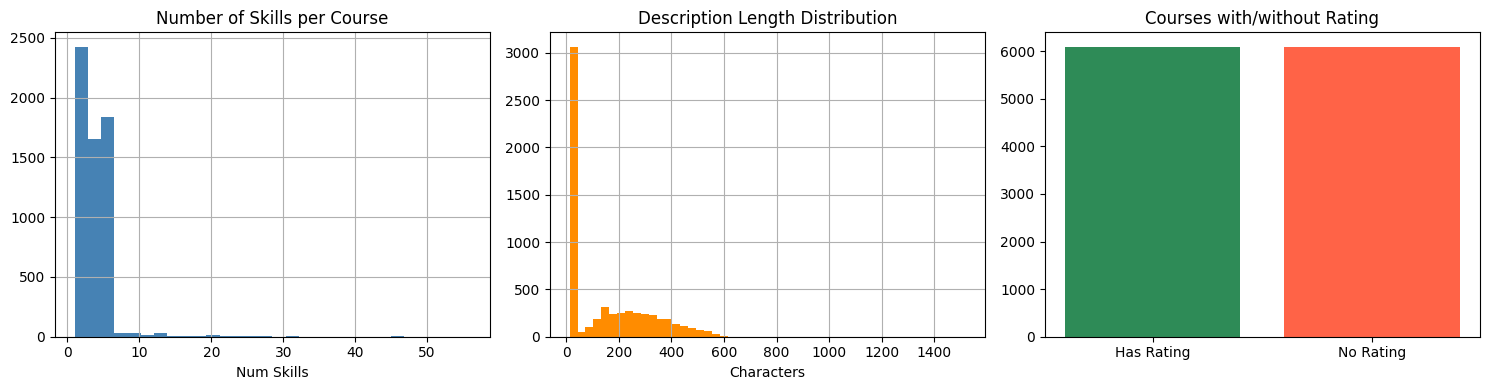

In [8]:
# Derived features distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
import matplotlib.pyplot as plt

cleaned_df['num_skills'].hist(bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Number of Skills per Course')
axes[0].set_xlabel('Num Skills')

cleaned_df['text_length'].hist(bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('Description Length Distribution')
axes[1].set_xlabel('Characters')

has_rating_counts = cleaned_df['has_rating'].value_counts()
axes[2].bar(['Has Rating', 'No Rating'], has_rating_counts.values, color=['seagreen', 'tomato'])
axes[2].set_title('Courses with/without Rating')

plt.tight_layout()
plt.show()

In [9]:
# combined_text sample
print('Sample combined_text (first 3 courses):')
for _, row in cleaned_df.head(3).iterrows():
    print(f'\n[course_id={row["course_id"]}]')
    print(row['combined_text'][:300], '...')

Sample combined_text (first 3 courses):

[course_id=0]
Fashion as Design Not specified Art History, Art, History, Creativity Beginner ...

[course_id=1]
Modern American Poetry Not specified Not specified Beginner ...

[course_id=2]
Pixel Art for Video Games Not specified Not specified Beginner ...


## 5. Save Cleaned Dataset

In [12]:
cleaned_df.head()

,Course Title,Rating,Level,Schedule,What you will learn,Skill gain,Modules,Instructor,Offered By,Keyword,Course Url,Duration to complete (Approx.),Number of Review,course_id,combined_text,has_rating,num_skills,text_length
0,Fashion as Design,4.8,Beginner,Flexible schedule,Not specified,"Art History, Art, History, Creativity","Introduction, Heroes, Silhouettes, Coutures, L...","Anna Burckhardt, Paola Antonelli, Michelle Mil...",The Museum of Modern Art,Arts and Humanities,https://www.coursera.org/learn/fashion-design,20.0,2813,0,"Fashion as Design Not specified Art History, A...",True,4,13
1,Modern American Poetry,4.4,Beginner,Flexible schedule,Not specified,Not specified,"Orientation, Module 1, Module 2, Module 3, Mod...",Cary Nelson,University of Illinois at Urbana-Champaign,Arts and Humanities,https://www.coursera.org/learn/modern-american...,34.0,100,1,Modern American Poetry Not specified Not speci...,True,1,13
2,Pixel Art for Video Games,4.5,Beginner,Flexible schedule,Not specified,Not specified,"Week 1: Introduction to Pixel Art, Week 2: Pix...","Andrew Dennis, Ricardo Guimaraes",Michigan State University,Arts and Humanities,https://www.coursera.org/learn/pixel-art-video...,9.0,227,2,Pixel Art for Video Games Not specified Not sp...,True,1,13
3,Distribución digital de la música independiente,0.0,Beginner,Flexible schedule,Not specified,Not specified,"Semana 1, Semana 2, Semana 3, Semana 4",Eduardo de la Vara Brown.,SAE Institute México,Arts and Humanities,https://www.coursera.org/learn/distribucion-di...,8.0,0,3,Distribución digital de la música independient...,True,1,13
4,The Blues: Understanding and Performing an Ame...,4.8,Beginner,Flexible schedule,Students will be able to describe the blues as...,"Music, Chord, Jazz, Jazz Improvisation","Blues Progressions – Theory and Practice , Blu...",Dariusz Terefenko,University of Rochester,Arts and Humanities,https://www.coursera.org/learn/the-blues,11.0,582,4,The Blues: Understanding and Performing an Ame...,True,4,161


In [10]:
import os
os.makedirs('../data/processed', exist_ok=True)

output_path = '../data/processed/courses_clean.csv'
cleaned_df.to_csv(output_path, index=False)
print(f'✅ Saved cleaned dataset to {output_path}')
print(f'   Shape: {cleaned_df.shape}')
print(f'   File size: {os.path.getsize(output_path) / 1024:.1f} KB')

✅ Saved cleaned dataset to ../data/processed/courses_clean.csv
   Shape: (6089, 18)
   File size: 5395.0 KB
